# ABOUT PHOTOBLEACHING:

In [19]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tifffile as tiff

import brighteyes_ism.analysis.APR_lib as apr
# from PIL import Image
import h5py
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max

import brighteyes_ism.analysis.Graph_lib as gra

from matplotlib.patches import Rectangle

import scipy as sc

from os import path
import plotly.express as px
from time import time

file = 'Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6'

# Qdots_37mW_FOV5um_64x64_100rip_5msPixel # fototubo?
# Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8 # 100μs
# Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7  # 100μs
# Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5  # 100μs
# Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4  # 100μs
# Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6  # 100μs

####################################################################################
################################################## INPUT SECTION:
####################################################################################

# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output
savenameSOFI = path.join(dir,'images','output','SOFI',file)
savenameTEST = path.join(dir,'images','output','TEST')

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]


f = h5py.File(filename + '.h5', 'r') # read h5 file

# ----------------- read header

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)
Fingerprint_h5 = group['Fingerprint'][()]

# ---------------- reading SPAD DATA

print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

# ----------------- display metadata

print('--------------------METADATA:--------------')
print('imgFormat: ',imgFormat,'x',imgFormat,'px')
print('depth (z): ', Depth)
print('FOV: ', ImgFoV,'μm')
print('pixelsize (x-y): ', pxsizex,'μm')
print('pixelsize (z): ', pxsizez,'μm')
print('ZSpan (z-range):', ZSpan,'μm')
print('Duration frame:', Duration,'ms')
print('Dwell time (time per pixel):', DwellTime,'ms')
print('---------------------------------------------')

# ---------------- fixing binning

# Ch,T,X,Y,R,Z
# print('Full data size: ' + str(data_h5.shape[0]))
# print('Total time bins (no channel distinction): ' +str(Endoftime_h5.shape[0]))

endtime=np.asarray(np.where(Endoftime_h5==1))[0,:]       #Cerco gli indici di Endoftime_h5 dove finiscono i pixels
# print('Scan pixels: ' + str(endtime.shape[0]))
# print('\nendtime: '+str(endtime[:10]))
v = np.max(np.diff(endtime))                             #Cerco la durata massima
# print('maximum temporal timetrace length: ' +str(v))                  
overflow = endtime[np.asarray(np.where(np.diff(endtime)==v))[0,:]+1]  #Indici di cut degli elementi in overflow
# print('\nOverflow: ' +str(overflow))
# print('Pixels in overflow: ' + str(overflow.shape[0]))

over_del = np.zeros(((overflow.shape[0]+1)*Nspad)).astype(np.int64)
for j in range(Nspad):
    over_del[(j)*overflow.shape[0]:overflow.shape[0]*(j+1)]= ((overflow*Nspad)+j)

g=np.linspace(0,48,49).astype(int)
if endtime[0]+1==v: 
    over_del[-49:]=((endtime[0]*Nspad)+g)
else:
    over_del=np.delete(over_del, np.linspace(over_del.shape[0]-Nspad, over_del.shape[0]-1).astype(int) , axis=(0))
    
# print('Bin in data_h5 to be removed: ' +str(over_del))

data_crop = np.delete(data_h5, over_del)
del over_del
del endtime
del g
del overflow
# print('\nFinal size of cropped data: ' +str(data_crop.shape[0]))
# print('Expected size: ' +str(Nspad*Depth*rep*imgFormat**2*(v-1)))

if not data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1):
    raise 'data error, bin not corresponding'
# print('size cropped == expected size: ', str(data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1)))

# ---------------------------- reshaping (z,rep,y,x,y,ch)

z_i, rep_i, y_i, x_i, t_i, ch_i = 0, 1, 2, 3, 4, 5 # indexes of reshaped data

fingerprint_meta = np.reshape(Fingerprint_h5, (spadFormat,spadFormat))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,Nspad)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,Nspad))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
# print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
# print('FoV [um]: ' + str(ImgFoV))
# if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
# print('Pixel size [um]: ' +str(pxsizex))
del data_h5 # free the memory
del Endoftime_h5

Opening time data...
Opening SPAD data...
Finished opening
--------------------METADATA:--------------
imgFormat:  64 x 64 px
depth (z):  1
FOV:  5.0 μm
pixelsize (x-y):  0.078125 μm
pixelsize (z):  100.0 μm
ZSpan (z-range): 100.0 μm
Duration frame: 499203.325155 ms
Dwell time (time per pixel): 121.87581180541993 ms
---------------------------------------------
Data format (z,rep,y,x,t,ch) (1, 60, 64, 64, 20, 49)


In [22]:
print(savenameTEST + '\\sofism')

c:\Users\jocar\Desktop\tesi\images\output\TEST\sofism


working on SOFISM d1... 
dataset D1 shape:  (64, 64, 1200, 5)
0 1 2 3 4 5 6 7 8 9 
done SOFISM D1: 0m3s


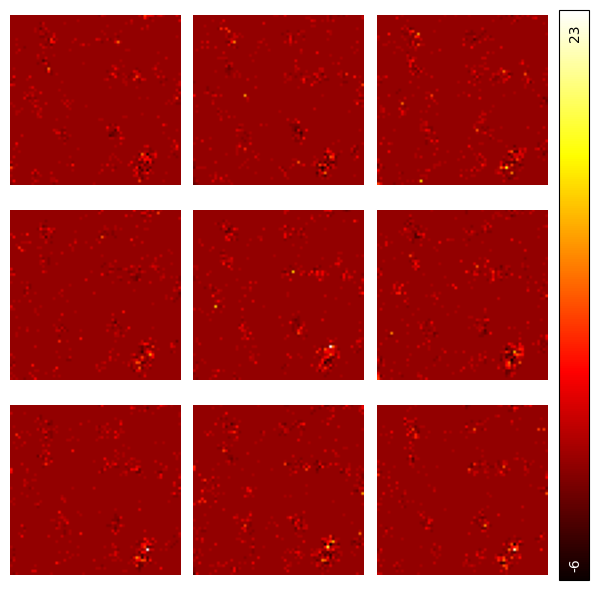

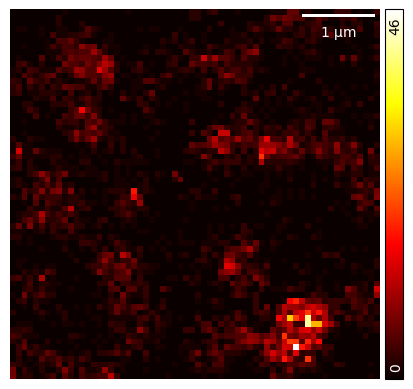

In [28]:
# SOFISIM D1

def batched_fft_correlate(sig1, sig2):
        """
        sig1, sig2: shape (ny, nx, nt)
        Returns correlation with shape (ny, nx, nt)
        mode='same' behavior
        """
        ny, nx, nt = sig1.shape
        # FFT length for 'same' mode
        nfft = nt
        f1 = np.fft.fft(sig1.reshape(-1, nt), n=nfft, axis=1)
        f2 = np.fft.fft(sig2.reshape(-1, nt), n=nfft, axis=1)
        corr = np.fft.ifft(f1 * np.conj(f2), axis=1).real
        # Shift so that center aligns like mode='same'
        corr = np.fft.fftshift(corr, axes=1)
        return corr.reshape(ny, nx, nt)

print('working on SOFISM d1... ')
start = time()
d1=np.asarray([data[0,:,:,:,:,i] for i in index1], dtype='float') # (z,rep,y,x,t,ch) -> (ch,rep,y,x,t)
d1=np.transpose(d1,(2,3,4,1,0)) # (ch,rep,y,x,t) -> (y,x,t,rep,ch)

d1 = d1.reshape(d1.shape[0],d1.shape[1],d1.shape[2]*d1.shape[3],d1.shape[4]) # (y,x,t,rep,ch) ->  (y,x,t*rep,ch)

ny, nx, nt, nch = d1.shape
imgN = int(nch * (nch - 1) / 2)
print('dataset D1 shape: ',d1.shape)

SOFISM_CORRELATION_0_d1 = np.zeros((ny, nx, imgN), dtype=np.int16)

    # Precompute mean-subtracted signals for all channels
d1_centered = d1 - d1.mean(axis=2, keepdims=True)

chindex=-1

import scipy as sc

for ch1 in range(nch):
    sig1 = d1_centered[:, :, :, ch1]  # shape (ny, nx, nt)
    for ch2 in range(ch1 + 1, nch, 1):
        chindex += 1
        print(chindex, end=' ')
        sig2 = d1_centered[:, :, :, ch2]
        # corr = batched_fft_correlate(sig1, sig2)
        SOFISM_CORRELATION_0_d1[:, :, chindex] = batched_fft_correlate(sig1, sig2)[:,:,0]  # take only the first time point

usf = 10  # upsampling factor = subpixel precision
ref_d1 = 5 #  5+4

shift_vec_D1, SOFISM_D1_CH = apr.APR( SOFISM_CORRELATION_0_d1, usf, ref_d1, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
SOFISM_D1 = SOFISM_D1_CH.sum(axis=2)

end = time()
TIME_SOFISM_D1 = end - start

print('\ndone SOFISM D1: ' + str(int(TIME_SOFISM_D1/60)) + 'm' + str(int(TIME_SOFISM_D1%60)) + 's')
fig_1 = gra.ShowDataset(SOFISM_CORRELATION_0_d1,normalize = True, colorbar=True) # SHOW 49 images

del SOFISM_D1_CH, shift_vec_D1 # SOFISM_CORRELATION_0_d1

tiff.imwrite(savenameTEST + '\\SOFISM_D1_10.tiff', SOFISM_D1/np.max(SOFISM_D1))

gra.ShowImg(SOFISM_D1,pxsize_x=pxsizex)
plt.show()

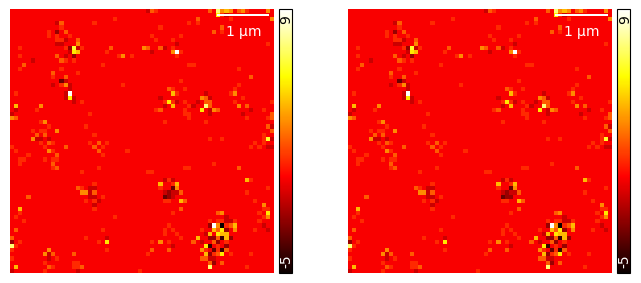

Indices where SOFISM_CORRELATION_0_d1[:,:,1] != SOFISM_CORRELATION_0_d1[:,:,5]:
(np.int64(45), np.int64(39)) -1 -2


In [13]:

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(8,16))

gra.ShowImg(SOFISM_CORRELATION_0_d1[:,:,1], pxsize_x = pxsizex, fig = fig, ax = ax0)
gra.ShowImg(SOFISM_CORRELATION_0_d1[:,:,5], pxsize_x = pxsizex, fig = fig, ax = ax1)

plt.show()

mask = SOFISM_CORRELATION_0_d1[:, :, 1] != SOFISM_CORRELATION_0_d1[:, :, 5]

# Get the indices (row, col) where it's false
false_indices = np.argwhere(mask)

# Print them
print("Indices where SOFISM_CORRELATION_0_d1[:,:,1] != SOFISM_CORRELATION_0_d1[:,:,5]:")
for idx in false_indices:
    print(tuple(idx),SOFISM_CORRELATION_0_d1[*idx, 1], SOFISM_CORRELATION_0_d1[*idx,5])


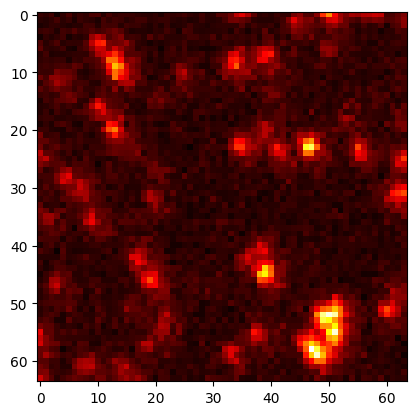

In [25]:
CENTRAL_SPAD = data[0, :, :, :, :, 24].sum(axis=(3, 0))
img_1 = CENTRAL_SPAD/np.max(CENTRAL_SPAD) #img_sum#np.sum(data,axis=(0,1,4))[:,:,24]#img_deconv[-1,...] #insert here the images 1 and 2 that you want to analyse
#img_2 = SOFISM_D3/np.max(SOFISM_D3) #img_ism_sum#srrf_ism_1[...]
plt.imshow(img_1, cmap='hot')
plt.show()

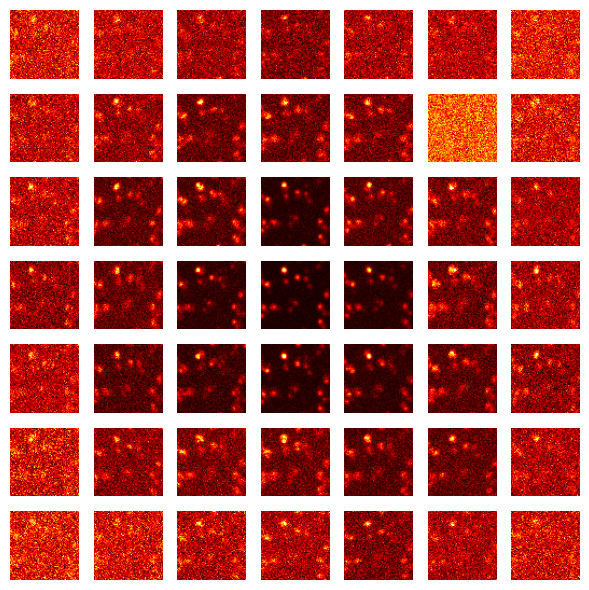

In [6]:
gra.ShowDataset(data[0,:,:,:,:,:].sum(axis=(0,3)))
plt.show()

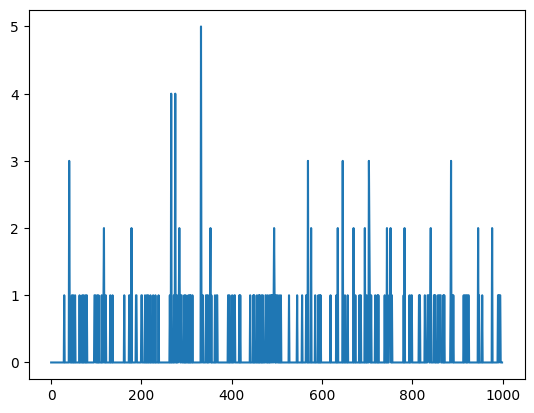

In [25]:
x = 22
y = 8

t = np.concatenate(data[0,:,y,x,:,24],axis=0)
t_2D = data[0,:,y,x,:,24] # (rep,t)

plt.plot(t)
plt.show()



In [22]:
import scipy
def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2))#/(m1*m2*len(t1)))
    return crosscorr

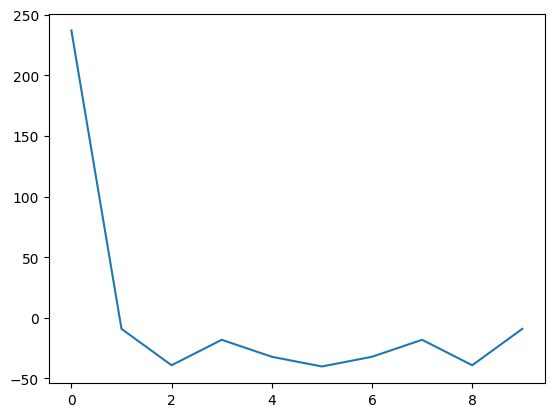

In [27]:
media = np.zeros(10)
for i in t_2D:
    media += correlazione(i, np.mean(i), i, np.mean(i))
plt.plot(media)
plt.show()

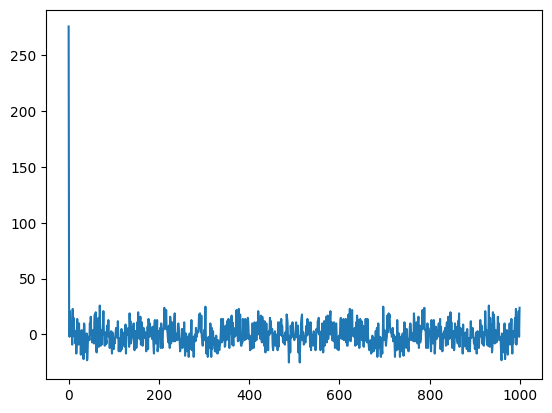

In [23]:
plt.plot(correlazione(t, np.mean(t), t, np.mean(t)))
plt.show()

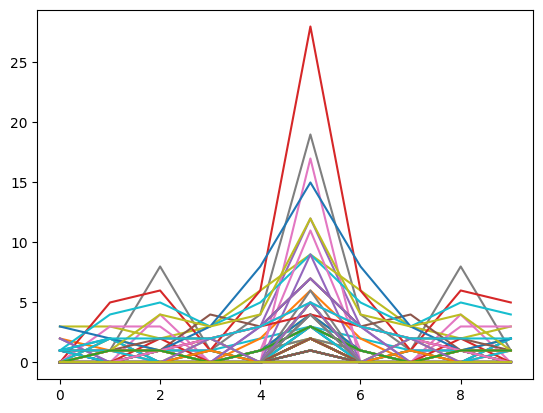

In [19]:
from scipy.signal import correlate

t_mean = np.reshape(t,(100,10))

for i in t_mean:
    plt.plot(correlate(i, i, mode='same'))

#plt.plot(correlate(t_mean, t_mean, mode='same'))
# plt.plot(correlate(t2, t2, mode='same'))
plt.show()

In [9]:
np.save('t.npy', t)

In [3]:
# # check the distribution of the photons:


# sz,srep,sy,sx,st,sch = data.shape
# times_for_channel = np.sum(np.reshape(np.transpose(data[0,:,:,:,:,:],(4,1,2,3,0)), (sch, sy*sx,st*srep)),axis=1)

In [4]:
# plt.hist(times_for_channel[24,:], bins = times_for_channel.shape[1])
# plt.show()

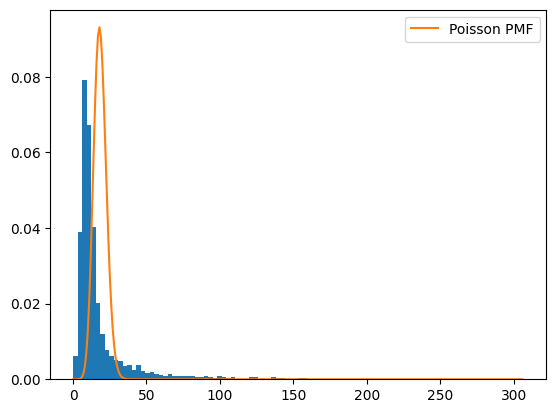

In [3]:
plt.hist(CENTRAL_SPAD.flatten(), density=True, bins=100)

from scipy.stats import poisson

lambda_ = np.mean(CENTRAL_SPAD)
x = np.arange(min(CENTRAL_SPAD.flatten()), max(CENTRAL_SPAD.flatten()))
plt.plot(x, poisson.pmf(x, lambda_), '-', label='Poisson PMF')
plt.legend()
plt.show()

In [7]:
xc=peak_local_max(img_1,min_distance=4, threshold_abs=0.3) # cordinates peaks
maxvalues = np.array([img_1[xc[i,0],xc[i,1]] for i in range(xc.shape[0])])

xc1 = xc # for filters like grater than less than ....

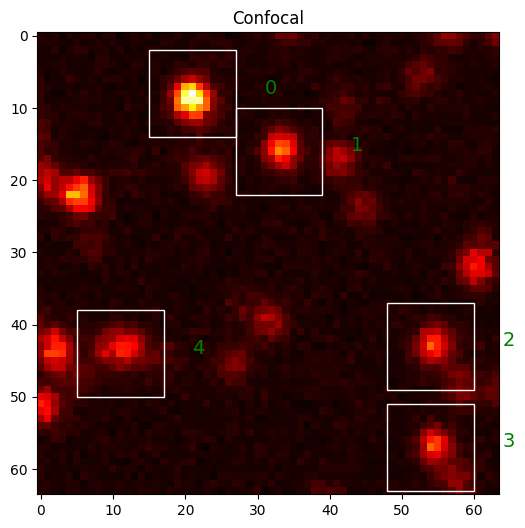

In [8]:
ROIsizeC = 12

# Remove specific particles
#Refresh the image above to see the updated indexes after every deletion!

wh = img_1.shape[0] # image height and width
halfsize = ROIsizeC / 2

# remove elements from borders
mask = (
    ((xc1 + (halfsize, halfsize)) < wh).all(axis=1) &
    ((xc1 - (halfsize, halfsize)) >= 0).all(axis=1)
)

xc1 = xc1[mask]
Npart = xc1.shape[0]

Npart = xc1.shape[0]
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.imshow(img_1,cmap='hot')#, vmax=300)
#ax[0].scatter(xc1[:,1],xc1[:,0])
ax.set_title('Confocal')
for l in range(Npart):
    rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
    ax.add_patch(rect)
    ax.text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='green')
    
# ax[1].imshow(img_2,cmap='hot')#, vmax=50)
# ax[1].set_title('ISM')
# for l in range(Npart):
#     rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
#     ax[1].add_patch(rect)
#     ax[1].text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='white')   
# ax = plt.gca()

In [9]:
rectagle_particles = []

for cord in xc1:
    yc,xc = cord
    rect = []
    for i in range(-int(ROIsizeC/2) + yc, yc +int(ROIsizeC/2)):
        for j in range(-int(ROIsizeC/2) + xc, xc +int(ROIsizeC/2)):
            rect.append((i,j))
    rectagle_particles.append(rect)

rectagle_particles = np.array(rectagle_particles)
print(rectagle_particles.shape)

(5, 144, 2)
